In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

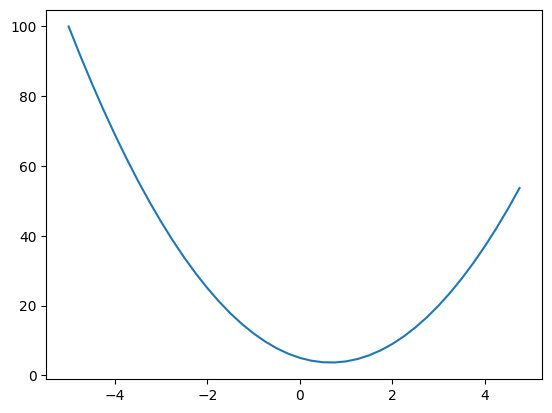

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [5]:
h = 0.000001

x = 2/3


(f(x+h) - f(x))/h

2.999378523327323e-06

In [6]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0

d = a * b + c

print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c += h
d2 = a * b + c

print("d1 - ", d1)
print("d2 - ", d2)
print("slope - ", (d2-d1)/h)

d1 -  4.0
d2 -  4.0001
slope -  0.9999999999976694


In [50]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * (other**-1)
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other): 
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f"**{other}")
        
        def _backward():
            self.grad += other*(self.data**(other-1)) * out.grad
        out._backward = _backward
    
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), "tanh")
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

In [51]:
a = Value(2.0)
b = Value(4.0)

a - b

Value(data=-2.0)

In [9]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [10]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad


e = a * b
d = e + c
L = d * f

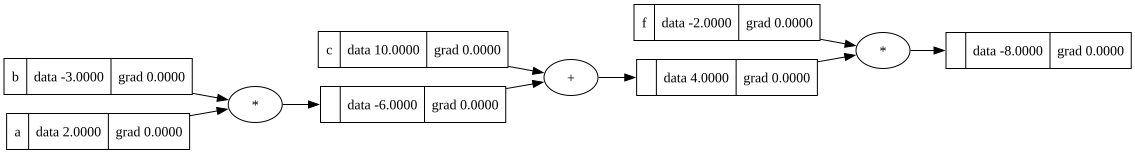

In [11]:
draw_dot(L)

### Manul backpropagation

- last first layer

dL/dd = ?

L = d * f

(f(x+h) - f(x))/ h

((d+h)*f - (d*f))/h

(d*f + h*f - d*f)/h

(h*f)/h

f


- last second layer

dL / dc = dL / dd * dd / dc

dd /dc ?

d = c + e

(f(x+h) - f(x))/h

((c+h + e) - (c+e))/h

(c + h + e - c - e)/h

(h)/h

dd / dc = 1.0;
dd / de = 1.0

dL / dc = dL / dd * dd / dc

dL / dc = -2.0 * 1.0

dL / dc = -2.0; 
dL / de = -2.0


- last third layer

dL / da = dL / dd * dd / de * de / da

de / da ?

(f(x+h)-f(x))/h

(((a+h)*b) - (a*b))/h

(a*b + h*b - a*b)/h

(h*b)/h

de / da  = b;
de / db = a

dL / da = dL / dd * dd / de * de / da; 
dL / da = -2.0 * 1.0 * -3.0

dL / da = dL / dd * dd / de * de / db; 
dL / db = -2.0 * 1.0 * 2.0



dL / da = -6.0; 
dL / db = 4.0


In [12]:
def lol():
    
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10, label="c")
    e = a * b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d*f; L.label = "L"
    L1 = L.data

    a = Value(2.0, label="a")
    a.data += h
    b = Value(-3.0, label="b")
    c = Value(10, label="c")
    e = a * b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d*f;L.label = "L"
    L2 = L.data
    
    print((L2-L1)/ h)
    
lol()

6.000000000000227


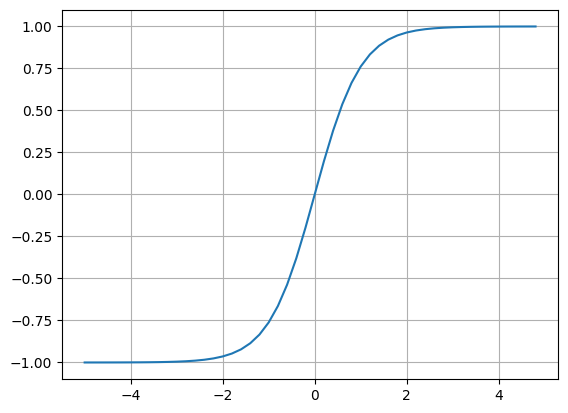

In [13]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid()

In [52]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1+ x2*w2'
n = x1w1x2w2 + b; n.label = "n"

o = n.tanh(); o.label = "o"

In [53]:
o.backward()

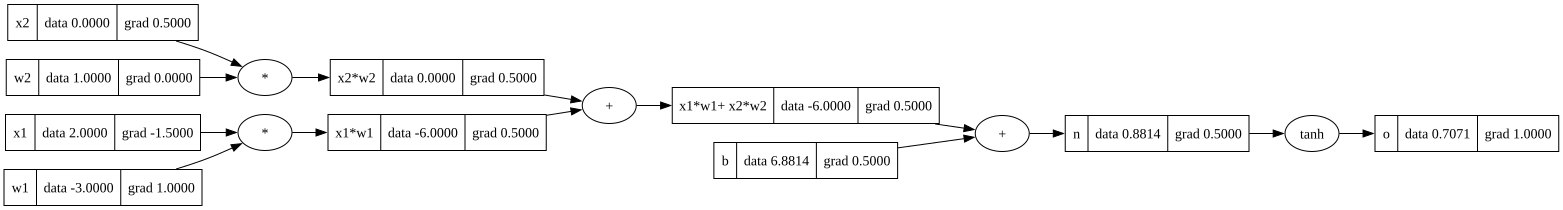

In [54]:
draw_dot(o)

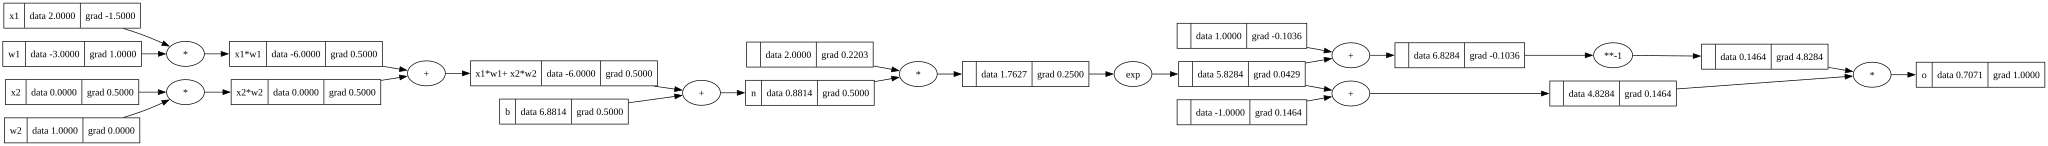

In [55]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1+ x2*w2'
n = x1w1x2w2 + b; n.label = "n"
# ---- 
e = (2*n).exp()

o = (e - 1)/(e + 1)
# ---- 
o.label = "o"
o.backward()

draw_dot(o)

- o = tanh(n)

do / dn = 1 - tanh(n)**2

do / dn = 1 - o**2

In [16]:
# x2.grad = .5
# w2.grad = 0.0
# w1.grad = 1.0
# x1.grad = -1.5

# x2w2.grad = .5
# x1w1.grad = .5
# x1w1x2w2.grad = .5
# b.grad = .5
# n.grad = .5
# o.grad = 1.0

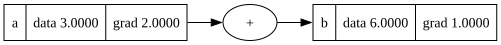

In [17]:
# bug in this approach

a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

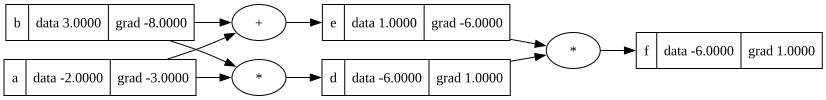

In [18]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')

d = a * b ; d.label = 'd'
e = a + b ; e.label = 'e'
f = d * e ; f.label = 'f'

f.backward()

draw_dot(f)

### Implementation in Pytorch

In [69]:
import torch

x1 = torch.Tensor([2.0]).double();              x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();              x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double();             w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();              w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())


0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [70]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)